For this problem set, I am working with quarterly data on Japan's trade and exchange rates. I pull in the trade-weighted nominal effective exchange rate (NEER) against a basket of currencies, the bilateral USD/JPY rate, and the EUR/JPY rate. On the trade side, I use import and export price indexes as well as real import and export quantities from the OECD.

My aim is to estimate exchange rate pass-through coefficients — first individually for each exchange rate, then jointly in a single regression — and to present both the raw data and the estimated coefficients visually.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# trade-weighted fx rate
fx_weighted = pd.read_excel('NEER_monthly_BIS.xlsx', 'NEER_monthly_BIS_simplified')

# fx rate against USD, EUR
fx_USD = pd.read_excel('Exchange rate(Yen vs Dollar and Euro)_IMF.xlsx', 'Exchange rate (vs USD)')
fx_EUR = pd.read_excel('Exchange rate(Yen vs Dollar and Euro)_IMF.xlsx', 'Exchange rate (vs EUR)')

# import & export price indexes: use 1 out 3 standards {Index, Yoy, Popp}
# I would use the Index columns, not YoY or PoP, because the assignment says to take logs and first differences yourself.
import_prices = pd.read_excel('Import_Export_price index_OECD.xlsx', 'Import')
export_prices = pd.read_excel('Import_Export_price index_OECD.xlsx', 'Export')

# real imports & exports - 'Real Im_Ex_OECD.xlsx'
trade = pd.read_excel(
    'Real Im_Ex_OECD.xlsx',
    sheet_name='Real Im_Ex_OECD'
)

trade = trade[['TIME_PERIOD','TRANSACTION','OBS_VALUE']]

trade['Quarter'] = pd.PeriodIndex(
    trade['TIME_PERIOD'], freq='Q'
)

# real import
import_real = trade[trade['TRANSACTION']=='P7']
import_real = import_real[['Quarter','OBS_VALUE']]
import_real = import_real.rename(
    columns={'OBS_VALUE':'real_imports'}
)

# real export
export_real = trade[trade['TRANSACTION']=='P6']

export_real = export_real[['Quarter','OBS_VALUE']]

export_real = export_real.rename(
    columns={'OBS_VALUE':'real_exports'}
)

Convert all data to Quarterly where necessary

The datasets arrive at different frequencies, so I need to align them all to quarterly before merging.

| Dataset | Original Frequency | What I did |
|---|---|---|
| NEER (BIS) | monthly | Converted to quarterly mean |
| USD/JPY (IMF) | quarterly | Parsed quarter directly |
| EUR/JPY (IMF) | quarterly | Parsed quarter directly |
| Import price index (OECD) | quarterly | Parsed quarter |
| Export price index (OECD) | quarterly | Parsed quarter |
| Real imports/exports (OECD) | quarterly | Parsed quarter |

In [3]:
# convert weighted fx rate to quarterly means
fx_weighted['Period'] = pd.to_datetime(fx_weighted['Period'])

fx_weighted['Quarter'] = fx_weighted['Period'].dt.to_period('Q')

fx_weighted_q = (
    fx_weighted
    .groupby('Quarter')['neer']
    .mean()
    .reset_index()
)

fx_weighted_q

,Quarter,neer
0,1994Q1,85.263333
1,1994Q2,89.176667
2,1994Q3,91.773333
3,1994Q4,91.633333
4,1995Q1,94.526667
...,...,...
124,2025Q1,75.353333
125,2025Q2,77.426667
126,2025Q3,74.833333
127,2025Q4,71.783333


In [4]:
# convert IMF exchange rates to quarter
fx_USD['Quarter'] = pd.PeriodIndex(fx_USD['INDICATOR'], freq='Q')

fx_USD = fx_USD.rename(
    columns={'Domestic currency per US Dollar':'usd_jpy'}
)

fx_USD = fx_USD[['Quarter','usd_jpy']]

fx_EUR['Quarter'] = pd.PeriodIndex(fx_EUR['INDICATOR'], freq='Q')

fx_EUR = fx_EUR.rename(
    columns={'Domestic currency per Euro':'eur_jpy'}
)

fx_EUR = fx_EUR[['Quarter','eur_jpy']]

In [5]:
# Parse OECD price indexes
# Use Index columns, not YoY or PoP.
# import
import_prices['Quarter'] = pd.PeriodIndex(
    import_prices['Period'], freq='Q'
)

import_prices = import_prices.rename(
    columns={'Index import':'import_price'}
)

import_prices = import_prices[['Quarter','import_price']]

# export
export_prices['Quarter'] = pd.PeriodIndex(
    export_prices['Period'], freq='Q'
)

export_prices = export_prices.rename(
    columns={'Index export':'export_price'}
)

export_prices = export_prices[['Quarter','export_price']]

Merge all datasets

In [6]:
# merge: how= inner (default)
# the resulting Quarter column will contain only the periods where every dataset has data.
df = (
    fx_weighted_q
    .merge(fx_USD, on='Quarter')
    .merge(fx_EUR, on='Quarter')
    .merge(import_prices, on='Quarter')
    .merge(export_prices, on='Quarter')
    .merge(import_real, on='Quarter')
    .merge(export_real, on='Quarter')
    .sort_values('Quarter')
)

# best way to deal with potentially missing data - interpolation, for macro data
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].interpolate(method='linear', limit_direction='both')

df

,Quarter,neer,usd_jpy,eur_jpy,import_price,export_price,real_imports,real_exports
0,2000Q1,101.923333,107.059657,105.609245,79.410612,118.915790,13199675,11560600
1,2000Q2,104.060000,106.607333,99.485792,78.532800,117.642520,13714750,11924525
2,2000Q3,104.483333,107.574013,97.380134,79.630065,117.256680,14067775,12123025
3,2000Q4,104.630000,109.820990,95.357740,81.260287,117.179512,14593475,12076600
4,2001Q1,96.950000,118.085640,109.018508,82.639705,122.619851,14620175,11640950
...,...,...,...,...,...,...,...,...
82,2020Q3,100.323333,106.143141,124.071844,82.169449,97.694608,20171475,20367250
83,2020Q4,99.233333,104.512558,124.672870,83.329415,99.469470,21353275,22101775
84,2021Q1,96.506667,105.906598,127.601312,83.925072,100.819909,21781250,23118400
85,2021Q2,93.466667,109.450065,131.979753,85.147739,101.977428,22814275,23679575


In [7]:
# check missing value
df.isna().sum()

Quarter         0
neer            0
usd_jpy         0
eur_jpy         0
import_price    0
export_price    0
real_imports    0
real_exports    0
dtype: int64

To work with stationary series, I transform all variables into log differences, which approximate quarter-on-quarter percentage changes:

$$\Delta \log(x_t) = \log(x_t) - \log(x_{t-1})$$

In [8]:
# take log and first diff
vars_to_transform = [
    'neer',
    'usd_jpy',
    'eur_jpy',
    'import_price',
    'export_price',
    'real_imports',
    'real_exports'
]

# log
for v in vars_to_transform:
    df[f'ln_{v}'] = np.log(df[v])

# first_diff
for v in vars_to_transform:
    df[f'dln_{v}'] = df[f'ln_{v}'].diff()

# remove first row since it's always NA
df = df.dropna().reset_index(drop=True)

# keep only the log-diff columns and quarter timestamp column
dln_cols = [col for col in df.columns if col.startswith('dln_')]
df = df[['Quarter'] + dln_cols]

df

,Quarter,dln_neer,dln_usd_jpy,dln_eur_jpy,dln_import_price,dln_export_price,dln_real_imports,dln_real_exports
0,2000Q2,0.020747,-0.004234,-0.059731,-0.011116,-0.010765,0.038280,0.030994
1,2000Q3,0.004060,0.009027,-0.021393,0.013875,-0.003285,0.025415,0.016509
2,2000Q4,0.001403,0.020673,-0.020987,0.020266,-0.000658,0.036688,-0.003837
3,2001Q1,-0.076235,0.072558,0.133882,0.016833,0.045382,0.001828,-0.036741
4,2001Q2,-0.014825,0.037818,-0.018662,0.012067,0.001258,-0.022155,-0.038823
...,...,...,...,...,...,...,...,...
81,2020Q3,-0.014186,-0.013560,0.045918,0.008429,0.015122,-0.077226,0.091842
82,2020Q4,-0.010924,-0.015481,0.004832,0.014018,0.018004,0.056936,0.081730
83,2021Q1,-0.027862,0.013250,0.023217,0.007123,0.013485,0.019844,0.044971
84,2021Q2,-0.032007,0.032911,0.033738,0.014463,0.011416,0.046337,0.023984


In [9]:
# save as csv first just in case
df.to_csv("pass_through_dataset.csv")

Before running regressions, check summary statistics and correlations. This helps understand relationships and detect weird values.

In [10]:
df.describe()

,dln_neer,dln_usd_jpy,dln_eur_jpy,dln_import_price,dln_export_price,dln_real_imports,dln_real_exports
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,-0.000952,0.000323,0.002394,0.000994,-0.001656,0.006110,0.008244
std,0.039404,0.038695,0.047789,0.047289,0.027337,0.031510,0.053517
min,-0.132451,-0.113044,-0.245773,-0.289808,-0.141408,-0.175349,-0.294167
25%,-0.019215,-0.022272,-0.018598,-0.013766,-0.012954,-0.005765,-0.007511
50%,-0.000801,0.001470,0.003837,0.002803,-0.001479,0.012093,0.014537
75%,0.015495,0.021092,0.027830,0.022043,0.013765,0.022999,0.031057
max,0.192214,0.129978,0.148268,0.103778,0.048181,0.060109,0.091871


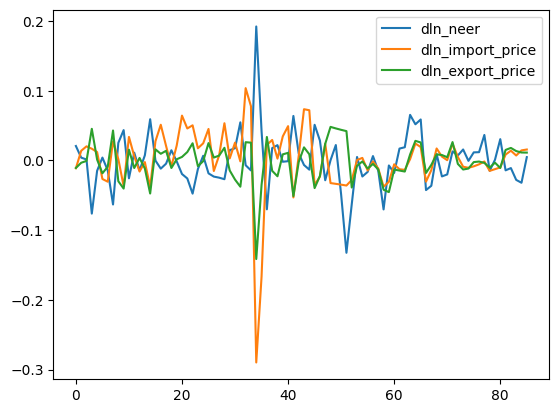

In [11]:
df[['dln_neer','dln_import_price','dln_export_price']].plot()
plt.show()

## Regression Framework

I estimate exchange rate pass-through by regressing log-differenced prices on log-differenced exchange rates. The general specification I use is:

$$\Delta \log(P_t^{imp}) = \alpha + \beta\,\Delta \log(ER_t) + \varepsilon_t$$

Here, $\beta$ is the pass-through coefficient. $\beta = 1$ means full pass-through — exchange rate changes are entirely reflected in prices. $\beta \in (0,1)$ implies partial pass-through, and $\beta = 0$ implies no pass-through at all.

### Import Price Pass-Through

I start by regressing log-differenced import prices on the log-differenced exchange rate:

$$\Delta \log(\textit{import\_price}) = \alpha + \beta\,\Delta \log(\textit{exchange\_rate})$$

In [12]:
# !pip install statsmodels

In [13]:
import statsmodels.api as sm

In [14]:
# neer
y = df['dln_import_price']

X = df[['dln_neer']]
X = sm.add_constant(X)

model_imp_neer = sm.OLS(y, X).fit()

# usd
X = df[['dln_usd_jpy']]
X = sm.add_constant(X)

model_imp_usd = sm.OLS(y, X).fit()

# eur
X = df[['dln_eur_jpy']]
X = sm.add_constant(X)

model_imp_eur = sm.OLS(y, X).fit()

# print(model_imp_neer.summary())
# print(model_imp_usd.summary())
# print(model_imp_eur.summary())

### Export Price Pass-Through

Next, I run the same specification for export prices:

$$\Delta \log(\textit{export\_price}) = \alpha + \beta\,\Delta \log(\textit{exchange\_rate})$$

In [15]:
y = df['dln_export_price']

X = df[['dln_neer']]
X = sm.add_constant(X)

model_exp_neer = sm.OLS(y, X).fit()

# usd
X = df[['dln_usd_jpy']]
X = sm.add_constant(X)

model_exp_usd = sm.OLS(y, X).fit()

# eur
X = df[['dln_eur_jpy']]
X = sm.add_constant(X)

model_exp_eur = sm.OLS(y, X).fit()

# print(model_exp_neer.summary())
# print(model_exp_usd.summary())
# print(model_exp_eur.summary())

### 3.3 Quantity Effects

I now check whether exchange rate movements feed through into trade volumes, not just prices. For imports:

$$\Delta \log(\textit{real\_imports}) = \alpha + \beta\,\Delta \log(\textit{exchange\_rate})$$

In [16]:
y = df['dln_real_imports']

X = df[['dln_neer']]
X = sm.add_constant(X)

model_q_imp_neer = sm.OLS(y, X).fit()

X = df[['dln_usd_jpy']]
X = sm.add_constant(X)

model_q_imp_usd = sm.OLS(y, X).fit()

X = df[['dln_eur_jpy']]
X = sm.add_constant(X)

model_q_imp_eur = sm.OLS(y, X).fit()

# print(model_q_imp_neer.summary())
# print(model_q_imp_usd.summary())
# print(model_q_imp_eur.summary())

And for exports:

$$\Delta \log(\textit{real\_exports}) = \alpha + \beta\,\Delta \log(\textit{exchange\_rate})$$

In [17]:
y = df['dln_real_exports']

X = df[['dln_neer']]
X = sm.add_constant(X)

model_q_exp_neer = sm.OLS(y, X).fit()

X = df[['dln_usd_jpy']]
X = sm.add_constant(X)

model_q_exp_usd = sm.OLS(y, X).fit()

X = df[['dln_eur_jpy']]
X = sm.add_constant(X)

model_q_exp_eur = sm.OLS(y, X).fit()

# print(model_q_exp_neer.summary())
# print(model_q_exp_usd.summary())
# print(model_q_exp_eur.summary())

### Simultaneous Regression (Multiple Exchange Rates)

Finally, I include all three exchange rates in a single regression to estimate the partial effect of each:

$$\Delta \log(\textit{import\_price}) = \alpha + \beta_1\,\Delta \log(\textit{NEER}) + \beta_2\,\Delta \log(\textit{USD}) + \beta_3\,\Delta \log(\textit{EUR}) + \varepsilon$$

This lets me see which exchange rate is driving import price changes after controlling for the others.

In [18]:
# import prices
y = df['dln_import_price']

X = df[['dln_neer','dln_usd_jpy','dln_eur_jpy']]
X = sm.add_constant(X)

model_imp_multi = sm.OLS(y, X).fit()

# export prices
y = df['dln_export_price']

X = df[['dln_neer','dln_usd_jpy','dln_eur_jpy']]
X = sm.add_constant(X)

model_exp_multi = sm.OLS(y, X).fit()

# print(model_imp_multi.summary())
# print(model_exp_multi.summary())

Do everything at once

1. Summary Table

In [19]:
# -----------------------------
# 0) CLEAN / PREP
# -----------------------------
df_reg = df.copy()

# If Quarter is still a column, keep it aside
if 'Quarter' in df_reg.columns:
    df_reg = df_reg.drop(columns=['Quarter'])

# Keep numeric columns only
df_reg = df_reg.select_dtypes(include='number').dropna().copy()

print("Shape of regression dataset:", df_reg.shape)
print("\nColumns:")
print(df_reg.columns.tolist())

# -----------------------------
# 1) DEFINE REGRESSIONS
# -----------------------------
# "separate" regressions
reg_specs = [
    ('Import Price ~ NEER',        'dln_import_price',  ['dln_neer']),
    ('Import Price ~ USDJPY',      'dln_import_price',  ['dln_usd_jpy']),
    ('Import Price ~ EURJPY',      'dln_import_price',  ['dln_eur_jpy']),
    
    ('Export Price ~ NEER',        'dln_export_price',  ['dln_neer']),
    ('Export Price ~ USDJPY',      'dln_export_price',  ['dln_usd_jpy']),
    ('Export Price ~ EURJPY',      'dln_export_price',  ['dln_eur_jpy']),
    
    ('Real Imports ~ NEER',        'dln_real_imports',  ['dln_neer']),
    ('Real Imports ~ USDJPY',      'dln_real_imports',  ['dln_usd_jpy']),
    ('Real Imports ~ EURJPY',      'dln_real_imports',  ['dln_eur_jpy']),
    
    ('Real Exports ~ NEER',        'dln_real_exports',  ['dln_neer']),
    ('Real Exports ~ USDJPY',      'dln_real_exports',  ['dln_usd_jpy']),
    ('Real Exports ~ EURJPY',      'dln_real_exports',  ['dln_eur_jpy']),
    
    # simultaneous regressions
    ('Import Price ~ ALL FX',      'dln_import_price',  ['dln_neer', 'dln_usd_jpy', 'dln_eur_jpy']),
    ('Export Price ~ ALL FX',      'dln_export_price',  ['dln_neer', 'dln_usd_jpy', 'dln_eur_jpy']),
    ('Real Imports ~ ALL FX',      'dln_real_imports',  ['dln_neer', 'dln_usd_jpy', 'dln_eur_jpy']),
    ('Real Exports ~ ALL FX',      'dln_real_exports',  ['dln_neer', 'dln_usd_jpy', 'dln_eur_jpy']),
]

# -----------------------------
# 2) RUN REGRESSIONS
# -----------------------------
results_rows = []
models = {}

for model_name, y_col, x_cols in reg_specs:
    temp = df_reg[[y_col] + x_cols].dropna().copy()
    y = temp[y_col]
    X = sm.add_constant(temp[x_cols])
    
    model = sm.OLS(y, X).fit()
    models[model_name] = model
    
    row = {
        'model': model_name,
        'dependent_var': y_col,
        'n_obs': int(model.nobs),
        'r_squared': model.rsquared,
        'adj_r_squared': model.rsquared_adj,
        'f_stat': model.fvalue,
        'f_pvalue': model.f_pvalue,
        'aic': model.aic,
        'bic': model.bic,
        'const': model.params.get('const', np.nan),
        'const_pval': model.pvalues.get('const', np.nan),
    }
    
    # save coefficient / se / p-value for each regressor
    for x in ['dln_neer', 'dln_usd_jpy', 'dln_eur_jpy']:
        row[f'beta_{x}'] = model.params.get(x, np.nan)
        row[f'se_{x}'] = model.bse.get(x, np.nan)
        row[f'pval_{x}'] = model.pvalues.get(x, np.nan)
    
    results_rows.append(row)

results_table = pd.DataFrame(results_rows)

# Nice formatting copy
results_table_rounded = results_table.copy()
num_cols = results_table_rounded.select_dtypes(include='number').columns
results_table_rounded[num_cols] = results_table_rounded[num_cols].round(4)

# -----------------------------
# 3) DESCRIPTIVE STATS
# -----------------------------
desc_table = df_reg.describe().T
desc_table['missing'] = df_reg.isna().sum()
desc_table = desc_table[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing']]
desc_table = desc_table.round(4)

# -----------------------------
# 4) CORRELATION MATRIX
# -----------------------------
corr_table = df_reg.corr().round(4)

# -----------------------------
# 5) OPTIONAL: STARRED COEFFICIENTS TABLE
# -----------------------------
def add_stars(beta, p):
    if pd.isna(beta):
        return np.nan
    if p < 0.01:
        return f"{beta:.4f}***"
    elif p < 0.05:
        return f"{beta:.4f}**"
    elif p < 0.10:
        return f"{beta:.4f}*"
    else:
        return f"{beta:.4f}"

coef_star_rows = []
for _, row in results_table.iterrows():
    coef_star_rows.append({
        'model': row['model'],
        'R2': round(row['r_squared'], 4),
        'N': int(row['n_obs']),
        'const': add_stars(row['const'], row['const_pval']),
        'dln_neer': add_stars(row['beta_dln_neer'], row['pval_dln_neer']),
        'dln_usd_jpy': add_stars(row['beta_dln_usd_jpy'], row['pval_dln_usd_jpy']),
        'dln_eur_jpy': add_stars(row['beta_dln_eur_jpy'], row['pval_dln_eur_jpy']),
    })

coef_table = pd.DataFrame(coef_star_rows)

# -----------------------------
# 6) DISPLAY / SAVE
# -----------------------------
print("\n==============================")
print("DESCRIPTIVE STATISTICS")
print("==============================")
print(desc_table)

print("\n==============================")
print("CORRELATION MATRIX")
print("==============================")
print(corr_table)

print("\n==============================")
print("REGRESSION SUMMARY TABLE")
print("==============================")
print(results_table_rounded)

print("\n==============================")
print("COMPACT COEFFICIENT TABLE")
print("==============================")
print(coef_table)

# Save to files if you want
desc_table.to_csv("descriptive_stats.csv")
corr_table.to_csv("correlation_matrix.csv")
results_table_rounded.to_csv("regression_summary_table.csv", index=False)
coef_table.to_csv("regression_compact_table.csv", index=False)

# If running in Jupyter, the last object displays nicely
results_table_rounded

Shape of regression dataset: (86, 7)

Columns:
['dln_neer', 'dln_usd_jpy', 'dln_eur_jpy', 'dln_import_price', 'dln_export_price', 'dln_real_imports', 'dln_real_exports']

DESCRIPTIVE STATISTICS
                  count    mean     std     min     25%     50%     75%  \
dln_neer           86.0 -0.0010  0.0394 -0.1325 -0.0192 -0.0008  0.0155   
dln_usd_jpy        86.0  0.0003  0.0387 -0.1130 -0.0223  0.0015  0.0211   
dln_eur_jpy        86.0  0.0024  0.0478 -0.2458 -0.0186  0.0038  0.0278   
dln_import_price   86.0  0.0010  0.0473 -0.2898 -0.0138  0.0028  0.0220   
dln_export_price   86.0 -0.0017  0.0273 -0.1414 -0.0130 -0.0015  0.0138   
dln_real_imports   86.0  0.0061  0.0315 -0.1753 -0.0058  0.0121  0.0230   
dln_real_exports   86.0  0.0082  0.0535 -0.2942 -0.0075  0.0145  0.0311   

                     max  missing  
dln_neer          0.1922        0  
dln_usd_jpy       0.1300        0  
dln_eur_jpy       0.1483        0  
dln_import_price  0.1038        0  
dln_export_price  0.0482 

,model,dependent_var,n_obs,r_squared,adj_r_squared,f_stat,f_pvalue,aic,bic,const,const_pval,beta_dln_neer,se_dln_neer,pval_dln_neer,beta_dln_usd_jpy,se_dln_usd_jpy,pval_dln_usd_jpy,beta_dln_eur_jpy,se_dln_eur_jpy,pval_dln_eur_jpy
0,Import Price ~ NEER,dln_import_price,86,0.2220,0.2127,23.9665,0.0000,-299.3904,-294.4817,0.0005,0.9200,-0.5654,0.1155,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
1,Import Price ~ USDJPY,dln_import_price,86,0.0714,0.0603,6.4541,0.0129,-284.1703,-279.2616,0.0009,0.8578,NaN,NaN,NaN,0.3264,0.1285,0.0129,NaN,NaN,NaN
2,Import Price ~ EURJPY,dln_import_price,86,0.2068,0.1974,21.9036,0.0000,-297.7313,-292.8226,-0.0001,0.9855,NaN,NaN,NaN,NaN,NaN,NaN,0.4500,0.0962,0.0000
3,Export Price ~ NEER,dln_export_price,86,0.3671,0.3596,48.7204,0.0000,-411.4064,-406.4977,-0.0021,0.3862,-0.4203,0.0602,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
4,Export Price ~ USDJPY,dln_export_price,86,0.1923,0.1827,20.0033,0.0000,-390.4377,-385.5290,-0.0018,0.5119,NaN,NaN,NaN,0.3098,0.0693,0.0000,NaN,NaN,NaN
5,Export Price ~ EURJPY,dln_export_price,86,0.3277,0.3197,40.9444,0.0000,-406.2141,-401.3054,-0.0024,0.3192,NaN,NaN,NaN,NaN,NaN,NaN,0.3275,0.0512,0.0000
6,Real Imports ~ NEER,dln_real_imports,86,0.0001,-0.0118,0.0119,0.9135,-347.6439,-342.7352,0.0061,0.0771,0.0095,0.0872,0.9135,NaN,NaN,NaN,NaN,NaN,NaN
7,Real Imports ~ USDJPY,dln_real_imports,86,0.0001,-0.0118,0.0054,0.9418,-347.6373,-342.7286,0.0061,0.0776,NaN,NaN,NaN,0.0065,0.0888,0.9418,NaN,NaN,NaN
8,Real Imports ~ EURJPY,dln_real_imports,86,0.0067,-0.0052,0.5631,0.4551,-348.2063,-343.2976,0.0062,0.0709,NaN,NaN,NaN,NaN,NaN,NaN,-0.0538,0.0717,0.4551
9,Real Exports ~ NEER,dln_real_exports,86,0.0795,0.0686,7.2574,0.0085,-263.6502,-258.7415,0.0079,0.1610,-0.3830,0.1422,0.0085,NaN,NaN,NaN,NaN,NaN,NaN


2. all graphs with coefficient and R² labels

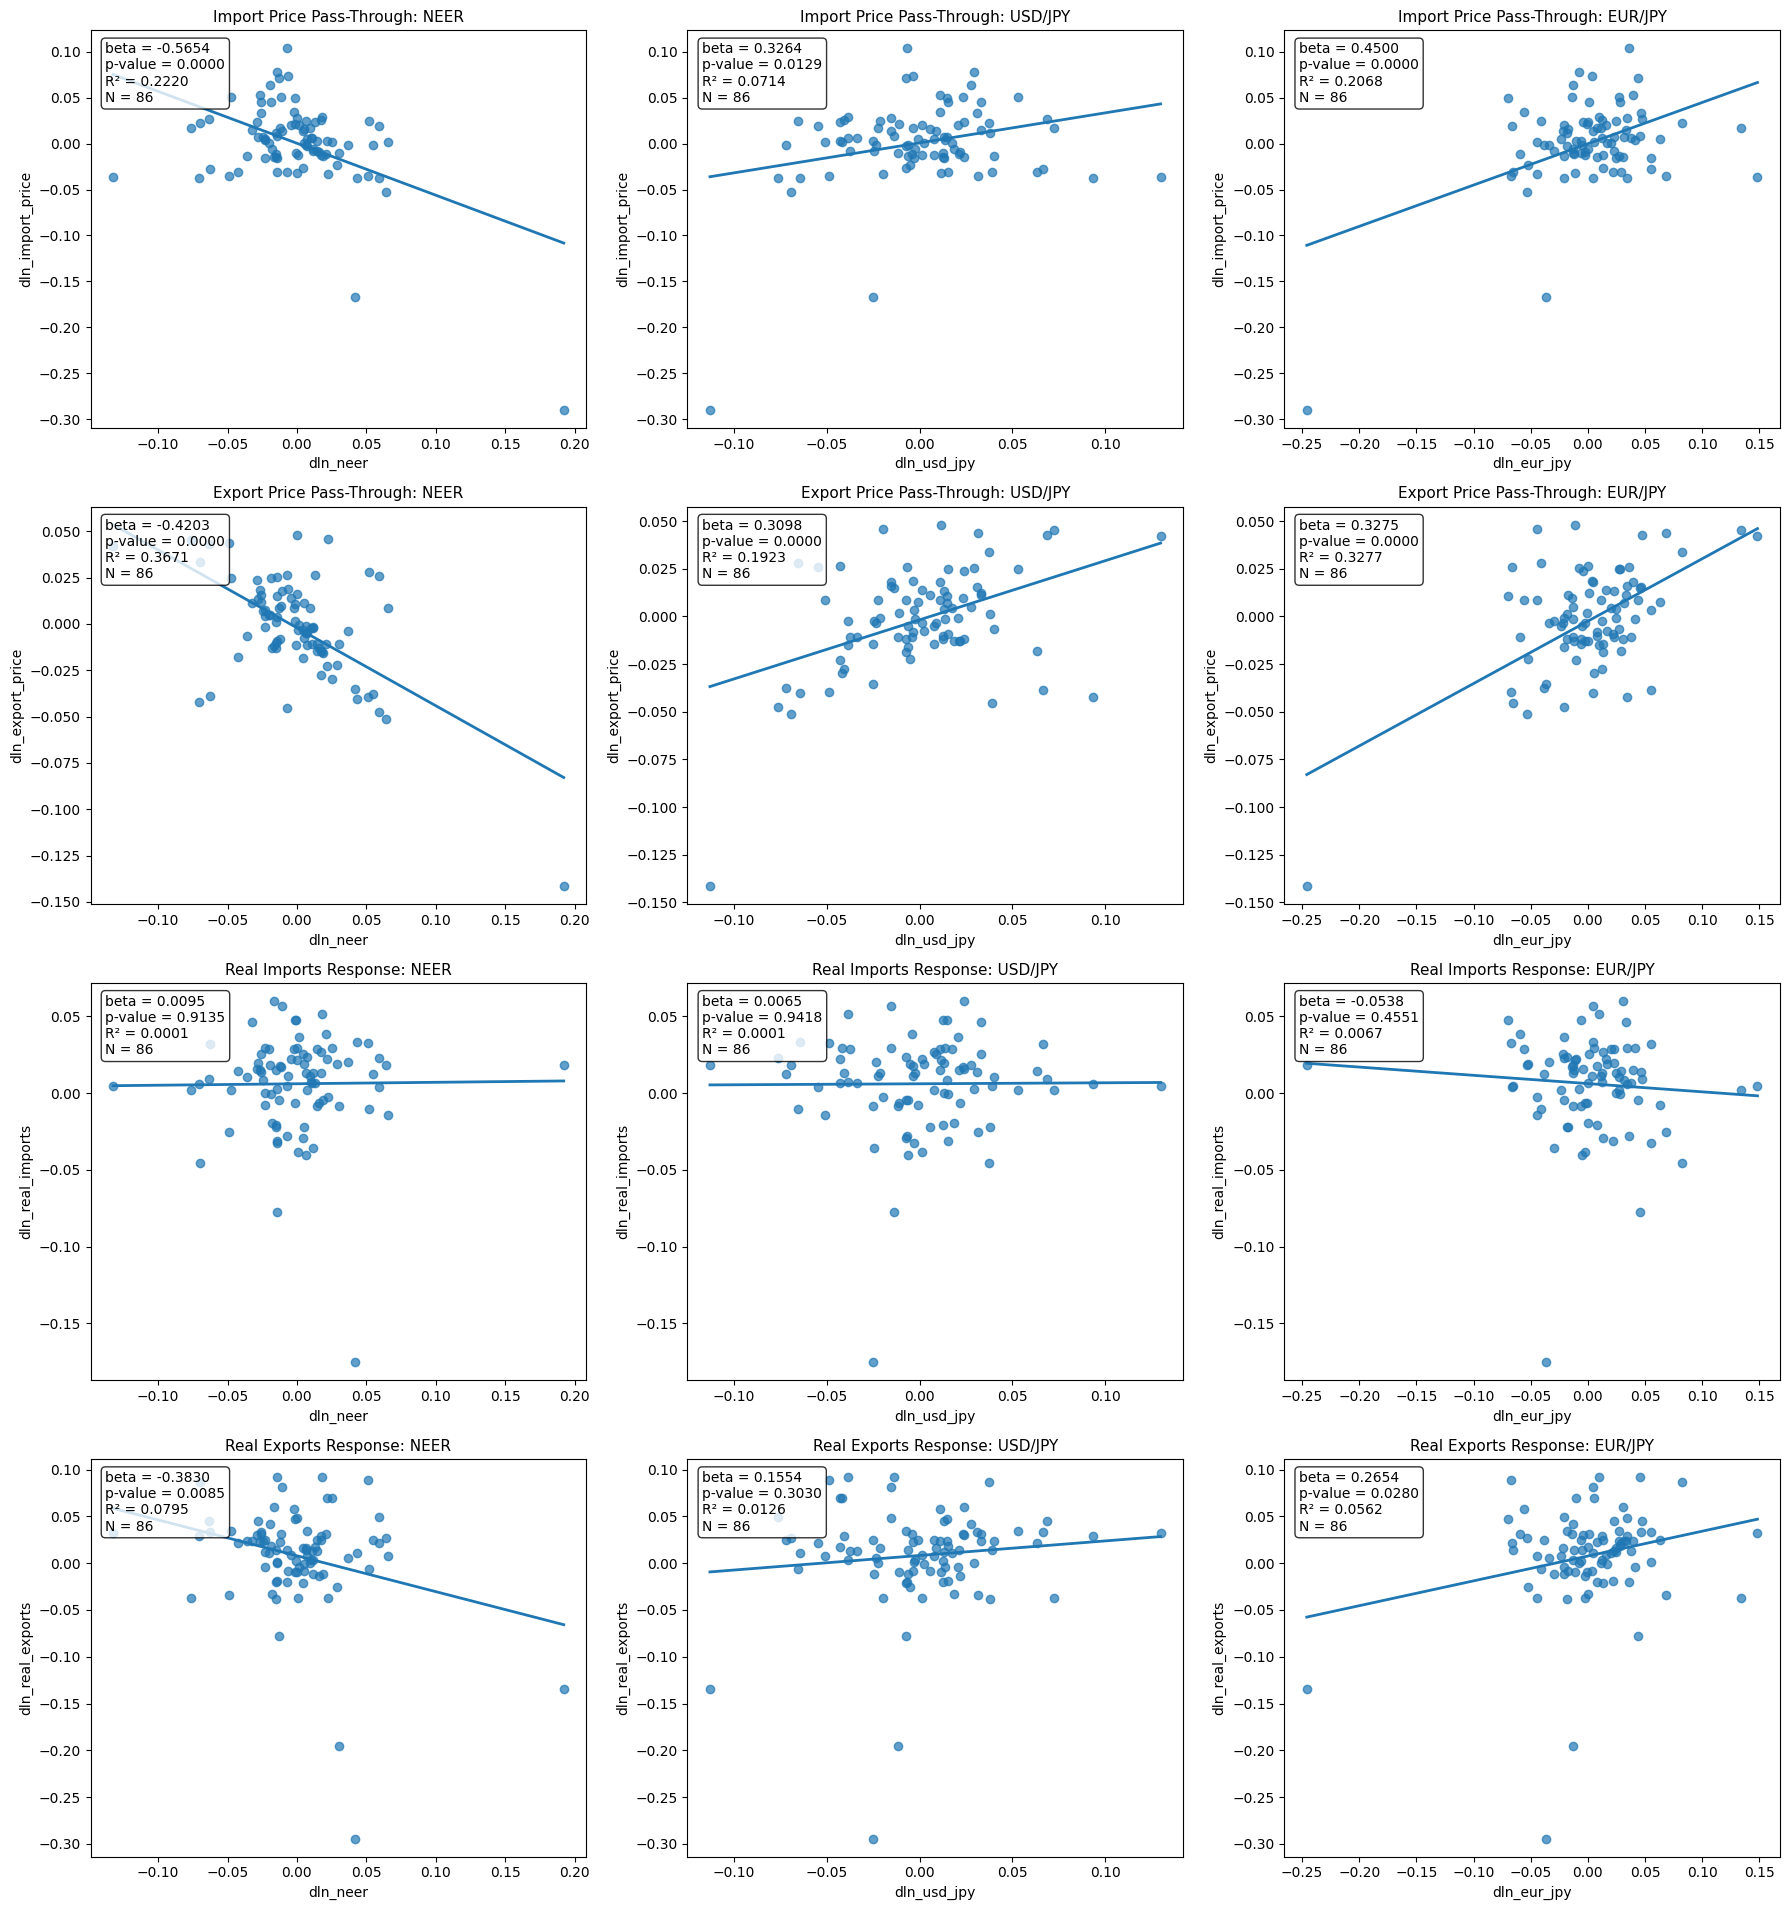

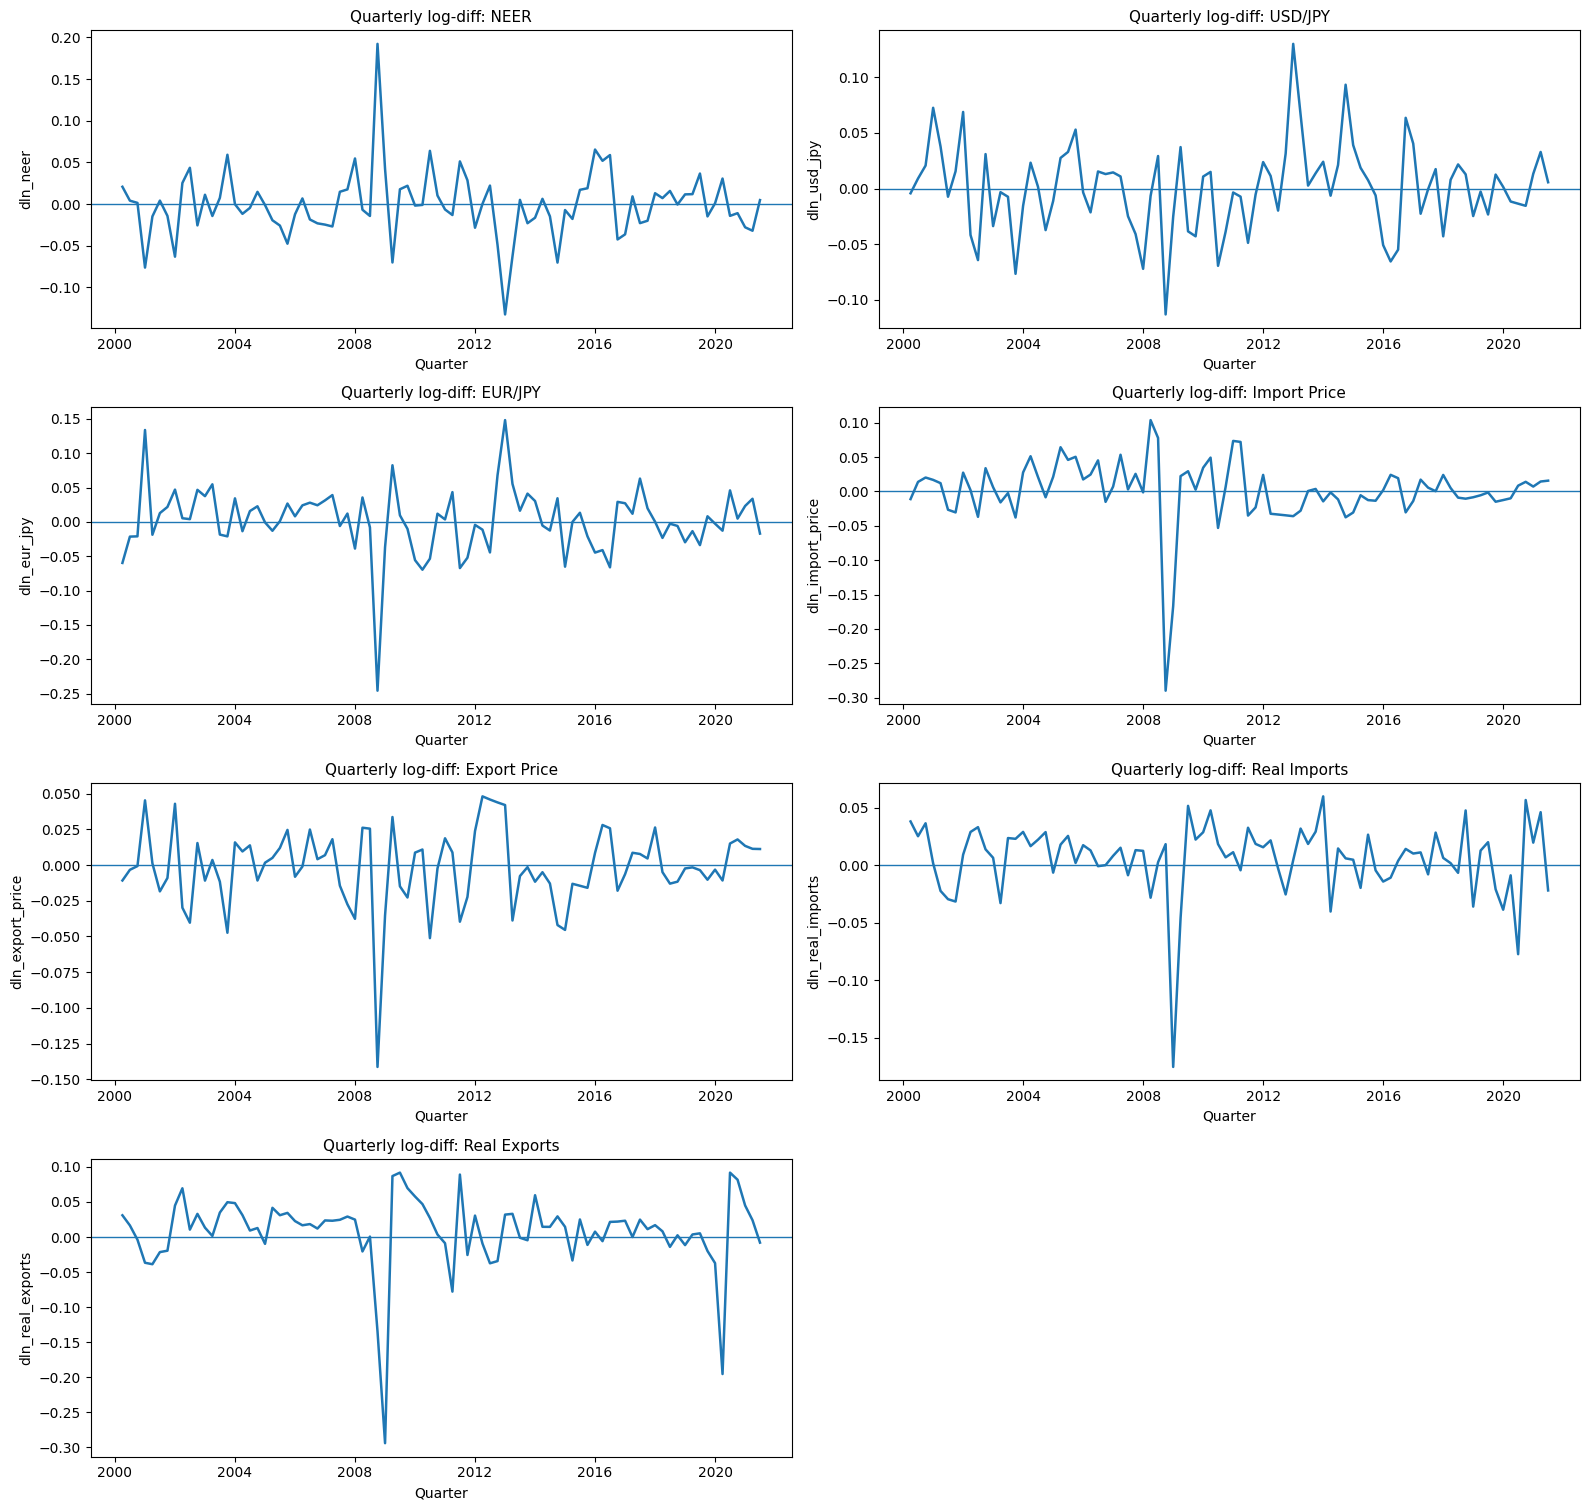

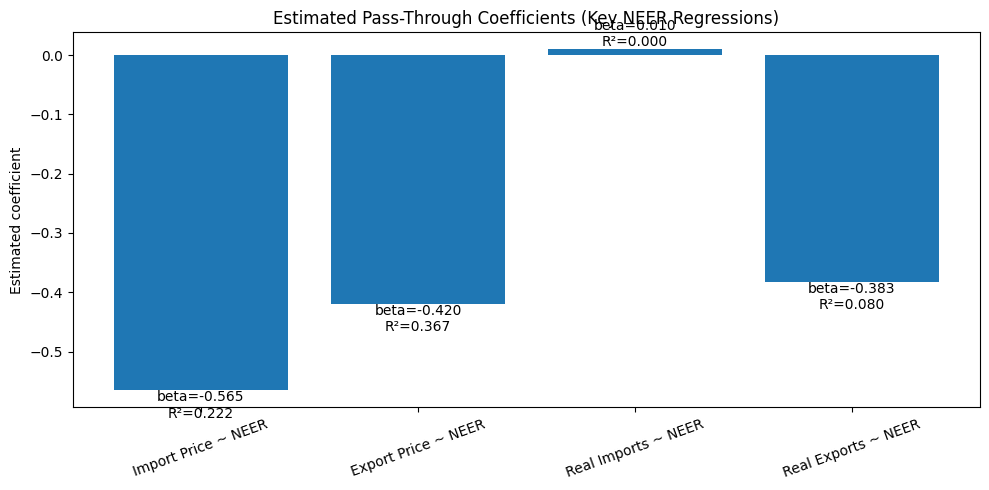

In [20]:
# ----------------------------------------
# 0) PREP
# ----------------------------------------
df_plot = df.copy()

if 'Quarter' in df_plot.columns:
    quarter_series = df_plot['Quarter']
else:
    quarter_series = None

# ----------------------------------------
# 1) HELPER FUNCTION
# ----------------------------------------
def make_scatter_reg_plot(ax, data, x_col, y_col, title, x_label=None, y_label=None):
    temp = data[[x_col, y_col]].dropna().copy()
    
    x = temp[x_col]
    y = temp[y_col]
    
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    
    # Scatter
    ax.scatter(x, y, alpha=0.7)
    
    # Fitted line
    x_sorted = np.sort(x.values)
    X_line = sm.add_constant(x_sorted)
    y_hat = model.predict(X_line)
    ax.plot(x_sorted, y_hat, linewidth=2)
    
    beta = model.params[x_col]
    pval = model.pvalues[x_col]
    r2 = model.rsquared
    nobs = int(model.nobs)
    
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(x_label if x_label else x_col)
    ax.set_ylabel(y_label if y_label else y_col)
    
    text_str = (
        f"beta = {beta:.4f}\n"
        f"p-value = {pval:.4f}\n"
        f"R² = {r2:.4f}\n"
        f"N = {nobs}"
    )
    
    ax.text(
        0.03, 0.97, text_str,
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    return model

# ----------------------------------------
# 2) DEFINE PLOTS
# ----------------------------------------
plot_specs = [
    # import price
    ('dln_neer',     'dln_import_price',  'Import Price Pass-Through: NEER'),
    ('dln_usd_jpy',  'dln_import_price',  'Import Price Pass-Through: USD/JPY'),
    ('dln_eur_jpy',  'dln_import_price',  'Import Price Pass-Through: EUR/JPY'),
    
    # export price
    ('dln_neer',     'dln_export_price',  'Export Price Pass-Through: NEER'),
    ('dln_usd_jpy',  'dln_export_price',  'Export Price Pass-Through: USD/JPY'),
    ('dln_eur_jpy',  'dln_export_price',  'Export Price Pass-Through: EUR/JPY'),
    
    # real imports
    ('dln_neer',     'dln_real_imports',  'Real Imports Response: NEER'),
    ('dln_usd_jpy',  'dln_real_imports',  'Real Imports Response: USD/JPY'),
    ('dln_eur_jpy',  'dln_real_imports',  'Real Imports Response: EUR/JPY'),
    
    # real exports
    ('dln_neer',     'dln_real_exports',  'Real Exports Response: NEER'),
    ('dln_usd_jpy',  'dln_real_exports',  'Real Exports Response: USD/JPY'),
    ('dln_eur_jpy',  'dln_real_exports',  'Real Exports Response: EUR/JPY'),
]

# ----------------------------------------
# 3) SCATTER + FITTED LINE PLOTS
# ----------------------------------------
n_plots = len(plot_specs)
ncols = 3
nrows = int(np.ceil(n_plots / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.8 * nrows))
axes = np.array(axes).reshape(-1)

plot_models = {}

for i, (x_col, y_col, title) in enumerate(plot_specs):
    plot_models[title] = make_scatter_reg_plot(
        ax=axes[i],
        data=df_plot,
        x_col=x_col,
        y_col=y_col,
        title=title,
        x_label=x_col,
        y_label=y_col
    )

# Turn off unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# ----------------------------------------
# 4) OPTIONAL: TIME-SERIES PANELS FOR MAIN VARIABLES
# ----------------------------------------
if quarter_series is not None:
    df_ts = df_plot.copy()
    try:
        # Works if Quarter is Period type
        df_ts['Quarter_ts'] = df_ts['Quarter'].dt.to_timestamp()
    except:
        df_ts['Quarter_ts'] = pd.to_datetime(df_ts['Quarter'], errors='coerce')
    
    ts_specs = [
        ('dln_neer', 'Quarterly log-diff: NEER'),
        ('dln_usd_jpy', 'Quarterly log-diff: USD/JPY'),
        ('dln_eur_jpy', 'Quarterly log-diff: EUR/JPY'),
        ('dln_import_price', 'Quarterly log-diff: Import Price'),
        ('dln_export_price', 'Quarterly log-diff: Export Price'),
        ('dln_real_imports', 'Quarterly log-diff: Real Imports'),
        ('dln_real_exports', 'Quarterly log-diff: Real Exports'),
    ]
    
    n_ts = len(ts_specs)
    ncols_ts = 2
    nrows_ts = int(np.ceil(n_ts / ncols_ts))
    
    fig, axes = plt.subplots(nrows=nrows_ts, ncols=ncols_ts, figsize=(16, 3.8 * nrows_ts))
    axes = np.array(axes).reshape(-1)
    
    for i, (col, title) in enumerate(ts_specs):
        temp = df_ts[['Quarter_ts', col]].dropna()
        axes[i].plot(temp['Quarter_ts'], temp[col], linewidth=1.8)
        axes[i].axhline(0, linewidth=1)
        axes[i].set_title(title, fontsize=11)
        axes[i].set_xlabel('Quarter')
        axes[i].set_ylabel(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# ----------------------------------------
# 5) OPTIONAL: BAR CHART OF COEFFICIENTS FOR KEY MODELS
# ----------------------------------------
key_models = [
    ('Import Price ~ NEER', 'dln_import_price', 'dln_neer'),
    ('Export Price ~ NEER', 'dln_export_price', 'dln_neer'),
    ('Real Imports ~ NEER', 'dln_real_imports', 'dln_neer'),
    ('Real Exports ~ NEER', 'dln_real_exports', 'dln_neer'),
]

bar_rows = []
for label, y_col, x_col in key_models:
    temp = df_plot[[x_col, y_col]].dropna()
    y = temp[y_col]
    X = sm.add_constant(temp[[x_col]])
    m = sm.OLS(y, X).fit()
    bar_rows.append({
        'model': label,
        'beta': m.params[x_col],
        'pvalue': m.pvalues[x_col],
        'R2': m.rsquared
    })

bar_df = pd.DataFrame(bar_rows)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bar_df['model'], bar_df['beta'])

for i, row in bar_df.iterrows():
    ax.text(
        i,
        row['beta'],
        f"beta={row['beta']:.3f}\nR²={row['R2']:.3f}",
        ha='center',
        va='bottom' if row['beta'] >= 0 else 'top'
    )

ax.set_title('Estimated Pass-Through Coefficients (Key NEER Regressions)')
ax.set_ylabel('Estimated coefficient')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()